# 🛠️ Travail réaliser

## Partie 1 — Préparation et exploration des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_excel('../data/data.xlsx',sheet_name="Online Retail")

In [3]:
print("SHape :",data.shape)
print("\nHead :",data.head())

SHape : (541909, 8)

Head :   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [4]:
print("Data types:",data.dtypes)
print("\nDescription :")
print(data.describe(include="all"))

Data types: InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Description :
        InvoiceNo StockCode                         Description  \
count    541909.0    541909                              540455   
unique    25900.0      4070                                4223   
top      573585.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER   
freq       1114.0      2313                                2369   
mean          NaN       NaN                                 NaN   
min           NaN       NaN                                 NaN   
25%           NaN       NaN                                 NaN   
50%           NaN       NaN                                 NaN   
75%           NaN       NaN                                 NaN   
max           NaN       NaN                      

In [5]:
missing=data.isnull().sum()

duplicates=data.duplicated().sum()

print("Missing values:\n",missing)

print("\nNumber of exact duplicates:", duplicates)

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Number of exact duplicates: 5268


In [6]:
cancelled = data["InvoiceNo"].astype(str).str.startswith("C")
print("Cancelled invoices:", cancelled.sum())

Cancelled invoices: 9288


In [7]:
invalid_quantity = data["Quantity"] <= 0

print("Quantity <= 0:", invalid_quantity.sum())

Quantity <= 0: 10624


In [8]:
invalid_price = data["UnitPrice"] <= 0

print("UnitPrice <= 0:", invalid_price.sum())

UnitPrice <= 0: 2517


In [9]:
anomalies=pd.DataFrame({
    "Anomaly":["Cancelled Invoices","Quantity<=0","UnitPrice<=0"],
    "Number of rows":[cancelled.sum(), invalid_quantity.sum(), invalid_price.sum()]
})

print(anomalies)

              Anomaly  Number of rows
0  Cancelled Invoices            9288
1         Quantity<=0           10624
2        UnitPrice<=0            2517


In [43]:
data_clean=data.copy()

data_clean = data_clean.dropna(subset=["CustomerID"]) #if the customerID is nan drop the row

non_product = ["POST","DOT","M","D","S","B","CRUK","AMAZONFEE","PADS","C2","BANK CHARGES"]

data_clean = data_clean[~data_clean["StockCode"].astype(str).str.upper().isin(non_product)]

data_clean=data_clean.drop_duplicates()

data_clean = data_clean[
    ~data_clean["InvoiceNo"].astype(str).str.startswith("C")
]

data_clean = data_clean[~data_clean["InvoiceNo"].astype(str).isin(["581483","541431","556444"])]

data_clean = data_clean[data_clean["Quantity"] > 0]

data_clean = data_clean[data_clean["UnitPrice"] > 0]

data_clean["InvoiceDate"] = pd.to_datetime(data_clean["InvoiceDate"])

data_clean["TotalPrice"] = (
    data_clean["Quantity"] * data_clean["UnitPrice"]
)

print(data_clean.shape)
print(data_clean.head())

(391147, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


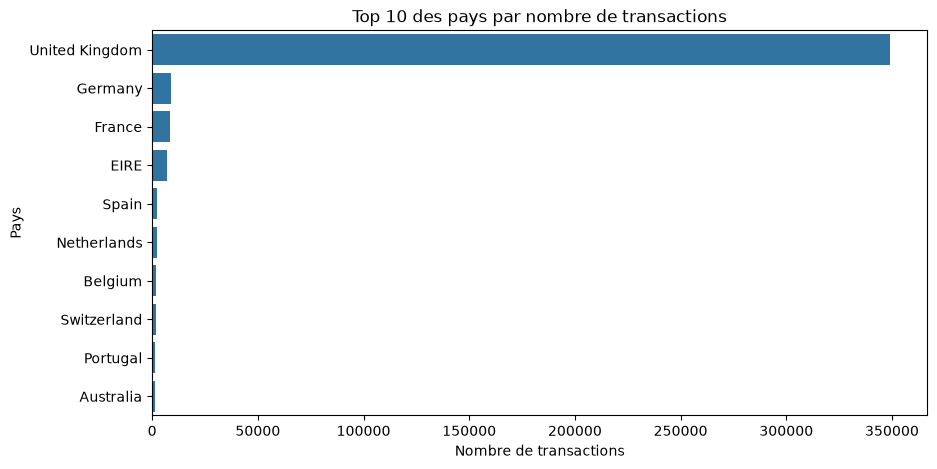

In [11]:
#Transactions by country
country_count=data_clean["Country"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=country_count.values, y=country_count.index)
plt.title("Top 10 des pays par nombre de transactions")
plt.xlabel("Nombre de transactions")
plt.ylabel("Pays")
plt.show()

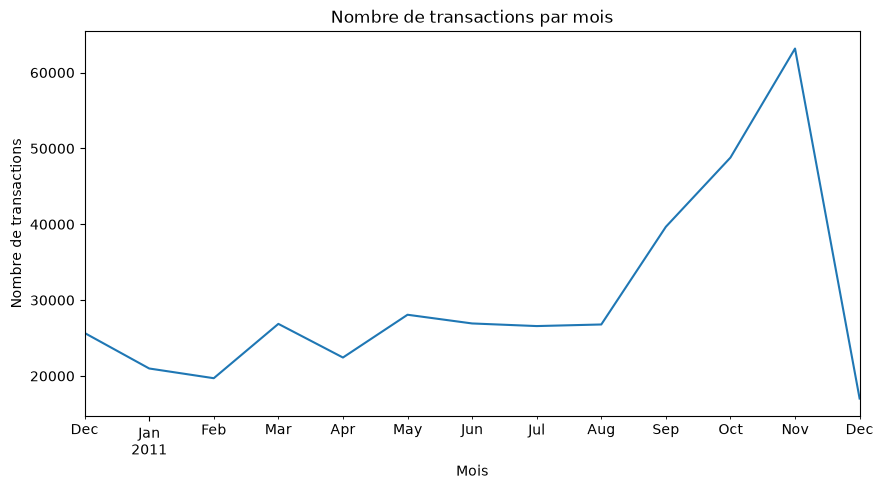

In [12]:
#Transactions by month

monthly=(data_clean.set_index("InvoiceDate").resample("ME").size())
plt.figure(figsize=(10, 5))
monthly.plot()
plt.title("Nombre de transactions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de transactions")
plt.show()

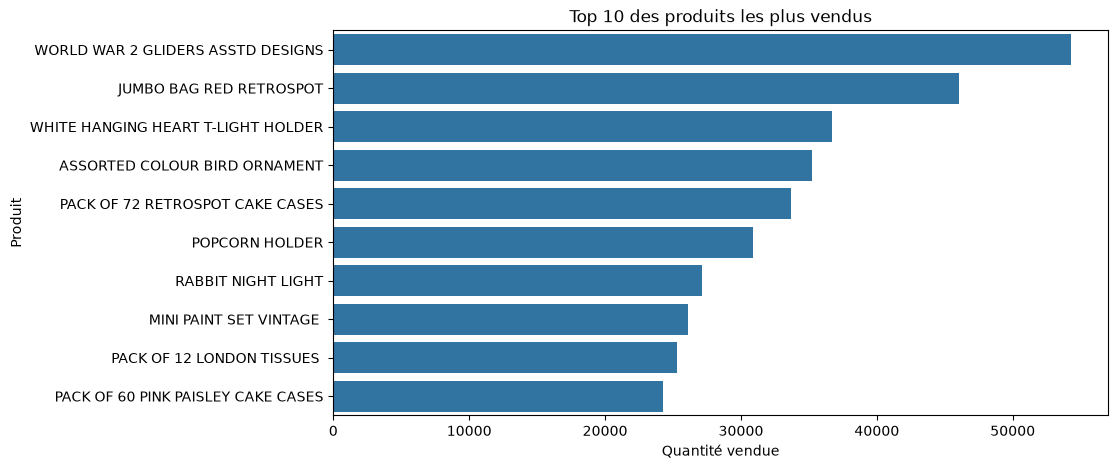

In [13]:
#Top products
top_products=(data_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values,y=top_products.index)
plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")
plt.show()

## Partie 2 — Indicateurs RFM

| Indicateur | Définition | Intérêt pour la segmentation |
|---|---|---|
| **Recence** | Nombre de jours entre le dernier achat du client et la date de référence (dernière date du dataset + 1 jour) | Un client récent est plus susceptible de racheter ; une récence élevée signale un risque d'inactivité |
| **Frequence** | Nombre de factures distinctes du client | Mesure la fidélité / régularité d'achat |
| **Montant** | Somme de `Quantity * UnitPrice` du client | Mesure la valeur monétaire du client |

Choix de préparation : lignes sans `CustomerID` supprimées (client non identifiable), doublons exacts supprimés, factures annulées (`C…`), quantités ≤ 0 et prix ≤ 0 exclus (retours/ajustements, non représentatifs du comportement d'achat).

In [14]:
print("Shape:", data_clean.shape)

print("\nColumns:")
print(data_clean.columns.tolist())

print("\nData types:")
print(data_clean.dtypes)

print("\nMissing values:")
print(data_clean.isnull().sum())

Shape: (392689, 9)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalPrice            float64
dtype: object

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


In [15]:
print("Number of transactions:", data_clean["InvoiceNo"].nunique())
print("Number of customers:", data_clean["CustomerID"].nunique())
print("\nDate range:")
print("First transaction:", data_clean["InvoiceDate"].min())
print("Last transaction:", data_clean["InvoiceDate"].max())

Number of transactions: 18529
Number of customers: 4337

Date range:
First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [42]:
data_clean["TotalPrice"].describe()

count    392689.000000
mean         21.906867
std          74.172664
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max        8142.750000
Name: TotalPrice, dtype: float64

In [17]:
customer_activity = (
    data_clean.groupby("CustomerID")
    .agg(
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum")
    )
    .sort_values(by="Monetary", ascending=False)
)
print(customer_activity.head(10))

            Frequency   Monetary
CustomerID                      
14646.0            73  280206.02
18102.0            60  259657.30
17450.0            46  194390.79
14911.0           201  143711.17
12415.0            21  124914.53
14156.0            55  117210.08
17511.0            31   91062.38
16029.0            63   80850.84
16684.0            28   66653.56
14096.0            17   65164.79


In [18]:
#recency
Last_date = data_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print(Last_date)

2011-12-10 12:50:00


In [19]:
customer_recency = data_clean.groupby("CustomerID")["InvoiceDate"].max()

In [20]:
customer_recency = (Last_date - customer_recency).dt.days

In [21]:
rfm = customer_activity.copy()
rfm["Recency"] = customer_recency
rfm.head(10)

,Frequency,Monetary,Recency
CustomerID,,,
14646.0,73,280206.02,2
18102.0,60,259657.30,1
17450.0,46,194390.79,8
14911.0,201,143711.17,1
12415.0,21,124914.53,24
14156.0,55,117210.08,10
17511.0,31,91062.38,3
16029.0,63,80850.84,39
16684.0,28,66653.56,4


In [22]:
#qcut divides your customers into groups based on their values
#5 divide the customers into 5 groups
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
print(rfm.head(10))

            Frequency   Monetary  Recency R_score
CustomerID                                       
14646.0            73  280206.02        2       5
18102.0            60  259657.30        1       5
17450.0            46  194390.79        8       5
14911.0           201  143711.17        1       5
12415.0            21  124914.53       24       4
14156.0            55  117210.08       10       5
17511.0            31   91062.38        3       5
16029.0            63   80850.84       39       3
16684.0            28   66653.56        4       5
14096.0            17   65164.79        4       5


In [23]:
rfm["F_score"] = pd.cut(rfm["Frequency"], [0,1,2,4,9,np.inf], labels=[1,2,3,4,5])
print(rfm.head(10))

            Frequency   Monetary  Recency R_score F_score
CustomerID                                               
14646.0            73  280206.02        2       5       5
18102.0            60  259657.30        1       5       5
17450.0            46  194390.79        8       5       5
14911.0           201  143711.17        1       5       5
12415.0            21  124914.53       24       4       5
14156.0            55  117210.08       10       5       5
17511.0            31   91062.38        3       5       5
16029.0            63   80850.84       39       3       5
16684.0            28   66653.56        4       5       5
14096.0            17   65164.79        4       5       5


In [24]:
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5])
print(rfm.head(10))

            Frequency   Monetary  Recency R_score F_score M_score
CustomerID                                                       
14646.0            73  280206.02        2       5       5       5
18102.0            60  259657.30        1       5       5       5
17450.0            46  194390.79        8       5       5       5
14911.0           201  143711.17        1       5       5       5
12415.0            21  124914.53       24       4       5       5
14156.0            55  117210.08       10       5       5       5
17511.0            31   91062.38        3       5       5       5
16029.0            63   80850.84       39       3       5       5
16684.0            28   66653.56        4       5       5       5
14096.0            17   65164.79        4       5       5       5


In [25]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

print(rfm.head(10))

            Frequency   Monetary  Recency R_score F_score M_score RFM_Score
CustomerID                                                                 
14646.0            73  280206.02        2       5       5       5       555
18102.0            60  259657.30        1       5       5       5       555
17450.0            46  194390.79        8       5       5       5       555
14911.0           201  143711.17        1       5       5       5       555
12415.0            21  124914.53       24       4       5       5       455
14156.0            55  117210.08       10       5       5       5       555
17511.0            31   91062.38        3       5       5       5       555
16029.0            63   80850.84       39       3       5       5       355
16684.0            28   66653.56        4       5       5       5       555
14096.0            17   65164.79        4       5       5       5       555


In [26]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    
    elif row["R_score"] >= 4 and row["F_score"] >= 3:
        return "Loyal Customers"
    
    elif row["R_score"] >= 4:
        return "Recent Customers"
    
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost Customers"
    
    else:
        return "Potential Customers"


In [27]:
rfm["Segment"]=rfm.apply(segment_customer,axis=1)
print(rfm.head(10))

            Frequency   Monetary  Recency R_score F_score M_score RFM_Score  \
CustomerID                                                                    
14646.0            73  280206.02        2       5       5       5       555   
18102.0            60  259657.30        1       5       5       5       555   
17450.0            46  194390.79        8       5       5       5       555   
14911.0           201  143711.17        1       5       5       5       555   
12415.0            21  124914.53       24       4       5       5       455   
14156.0            55  117210.08       10       5       5       5       555   
17511.0            31   91062.38        3       5       5       5       555   
16029.0            63   80850.84       39       3       5       5       355   
16684.0            28   66653.56        4       5       5       5       555   
14096.0            17   65164.79        4       5       5       5       555   

                        Segment  
CustomerID       

In [28]:
rfm["Segment"].value_counts()

Segment
Lost Customers         1326
Potential Customers     858
Champions               795
Recent Customers        526
Loyal Customers         450
At Risk                 382
Name: count, dtype: int64

In [29]:
# How recently do Champions purchase?
# How frequently do Loyal Customers purchase?
# How much money do At Risk customers generate?
# Which segments contain the most customers?

rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,137.269634,4.361257,1570.798249
Champions,12.188679,12.623899,6894.027459
Lost Customers,209.489442,1.278281,452.623704
Loyal Customers,16.080000,3.682222,1240.794313
Potential Customers,52.315851,3.106061,1281.406620
Recent Customers,17.621673,1.539924,501.531521


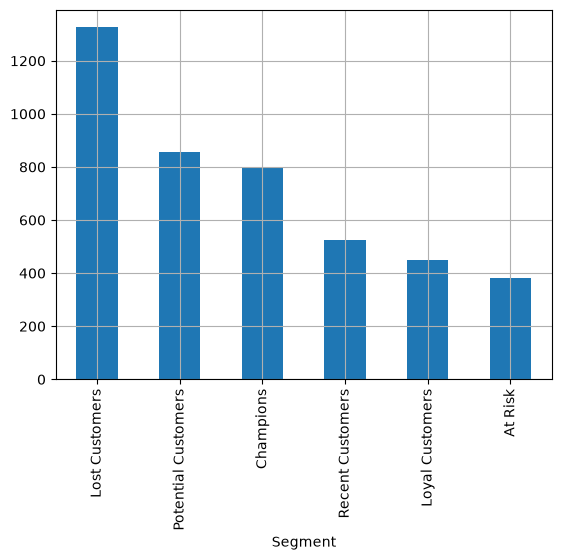

In [30]:
rfm["Segment"].value_counts().plot(kind="bar").grid()

In [31]:
#percentage of all customers belongs to each segment
segment_percentage = (
    rfm["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(segment_percentage)

Segment
Lost Customers         30.57
Potential Customers    19.78
Champions              18.33
Recent Customers       12.13
Loyal Customers        10.38
At Risk                 8.81
Name: proportion, dtype: float64


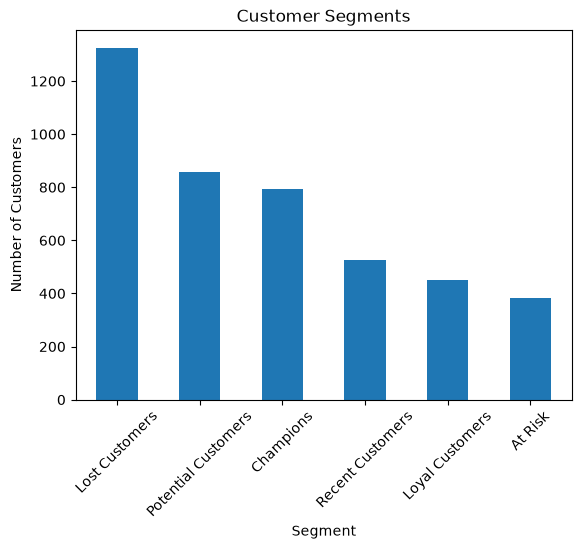

In [32]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [33]:
rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

Segment
Champions              6894.027459
At Risk                1570.798249
Potential Customers    1281.406620
Loyal Customers        1240.794313
Recent Customers        501.531521
Lost Customers          452.623704
Name: Monetary, dtype: float64

In [34]:
segment_analysis = rfm.groupby("Segment").agg(
    Customers=("Monetary", "count"),
    Avg_Monetary=("Monetary", "mean")
)

segment_analysis

,Customers,Avg_Monetary
Segment,,
At Risk,382,1570.798249
Champions,795,6894.027459
Lost Customers,1326,452.623704
Loyal Customers,450,1240.794313
Potential Customers,858,1281.406620
Recent Customers,526,501.531521


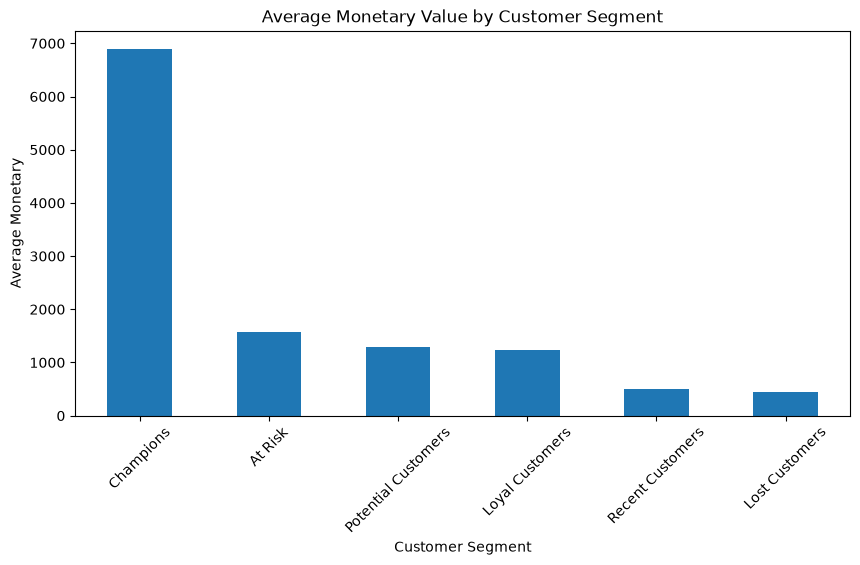

In [35]:
import matplotlib.pyplot as plt

rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary")
plt.xticks(rotation=45)
plt.show()

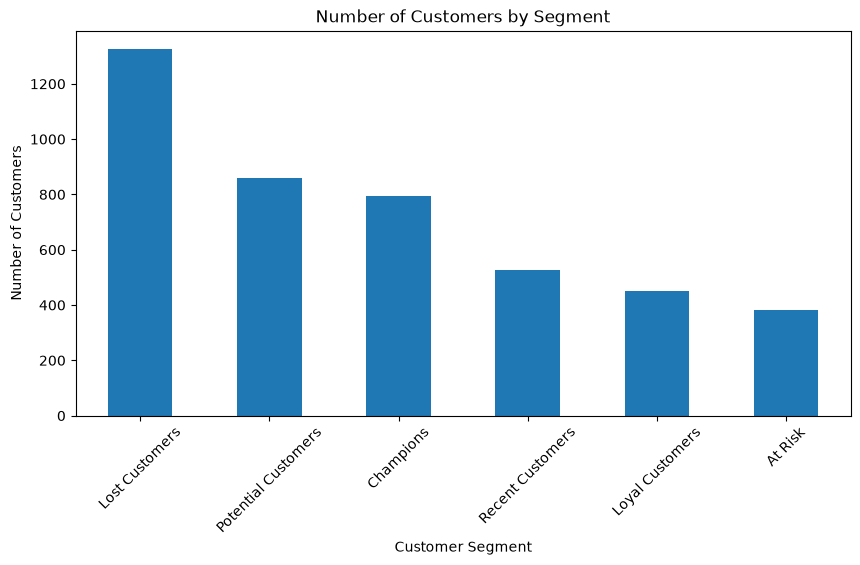

In [36]:
rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [37]:
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,137.27,4.36,1570.80
Champions,12.19,12.62,6894.03
Lost Customers,209.49,1.28,452.62
Loyal Customers,16.08,3.68,1240.79
Potential Customers,52.32,3.11,1281.41
Recent Customers,17.62,1.54,501.53


---
# Partie 3 — Préparation des variables pour le clustering

           Recency    Frequency       Monetary
count  4337.000000  4337.000000    4337.000000
mean     92.529859     4.272308    1983.533709
std      99.968030     7.698861    8528.168626
min       1.000000     1.000000       2.900000
25%      18.000000     1.000000     306.450000
50%      51.000000     2.000000     668.430000
75%     142.000000     5.000000    1654.310000
max     374.000000   209.000000  280206.020000

Skewness :
 Recency       1.245834
Frequency    12.065642
Monetary     20.753888
dtype: float64


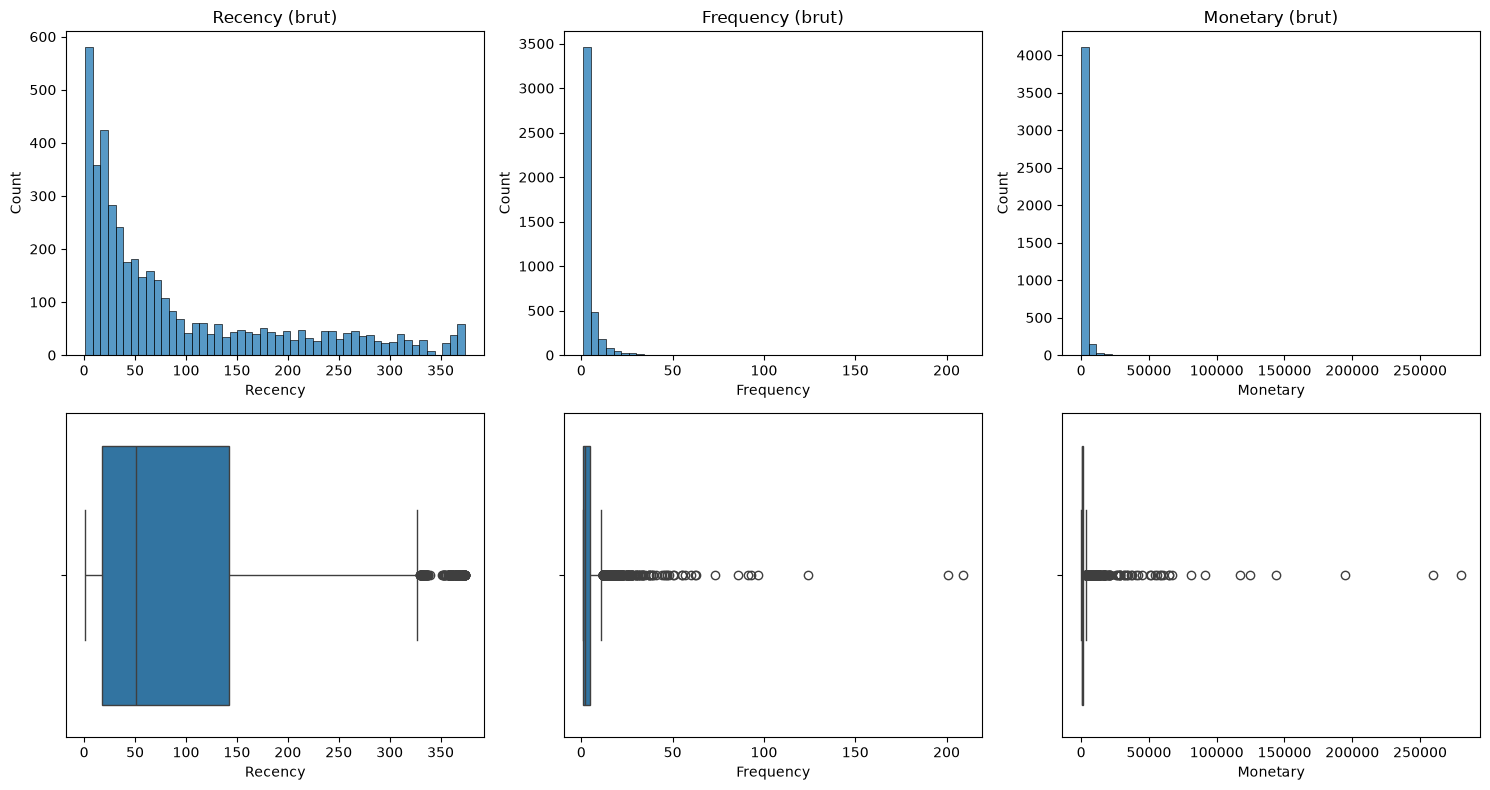

In [38]:
features = ["Recency", "Frequency", "Monetary"]
print(rfm[features].describe())
print("\nSkewness :\n", rfm[features].skew())

fig,axes=plt.subplots(2,3,figsize=(15,8))
for j,col in enumerate(features):
    sns.histplot(rfm[col],bins=50,ax=axes[0,j])
    axes[0,j].set_title(f"{col} (brut)")
    sns.boxplot(x=rfm[col],ax=axes[1,j])
plt.tight_layout()
plt.show()


Les variables Frequence et Montant sont très asymétriques à droite (quelques clients extrêmes). K-Means, basé sur les distances euclidiennes, serait dominé par ces valeurs extrêmes et par l'échelle de Montant.

Traitement : `log1p` (réduit l'asymétrie, valeurs strictement positives donc sans risque) puis `StandardScaler` (met les trois variables à la même échelle).

Skewness après log1p :
 Recency     -0.378777
Frequency    1.208555
Monetary     0.355680
dtype: float64


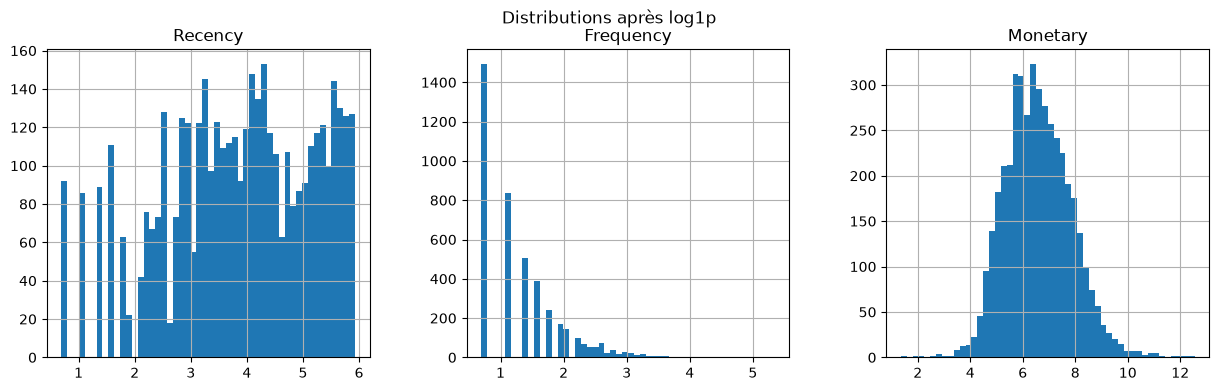

In [39]:
from sklearn.preprocessing import StandardScaler

X_log=np.log1p(rfm[features])
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_log)

print("Skewness après log1p :\n", X_log.skew())

X_log.hist(bins=50, figsize=(15, 4), layout=(1, 3))
plt.suptitle("Distributions après log1p")
plt.show()

---

# Partie 4 — Segmentation avec K-Means

## 4.1 Recherche d'un nombre de clusters pertinent

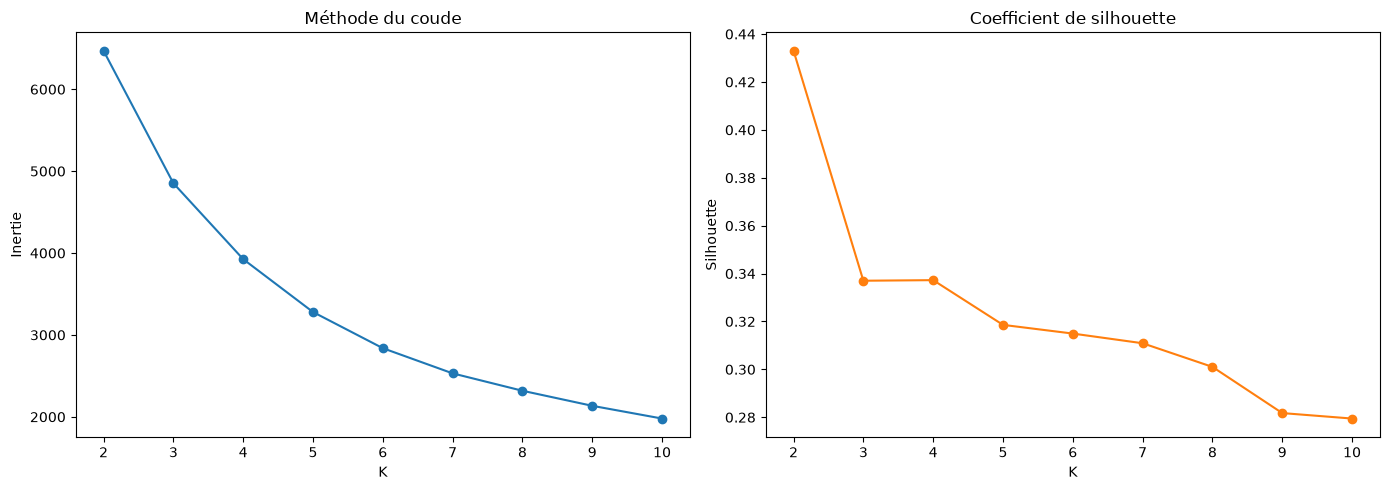

    K    Inertie  Silhouette
0   2  6470.5667      0.4330
1   3  4852.7268      0.3370
2   4  3925.3038      0.3373
3   5  3279.6766      0.3186
4   6  2838.1676      0.3150
5   7  2530.6011      0.3109
6   8  2318.1302      0.3010
7   9  2134.2386      0.2818
8  10  1978.7401      0.2795
K suggéré par la silhouette : 2


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range=range(2,11)
inertias=[]
silhouettes=[]
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    lab=kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled,lab))

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(list(k_range),inertias,marker="o")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertie")
axes[1].plot(list(k_range), silhouettes, marker="o", color="tab:orange")
axes[1].set_title("Coefficient de silhouette")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

res=pd.DataFrame({"K":list(k_range), "Inertie": inertias, "Silhouette": silhouettes})
print(res.round(4))
print("K suggéré par la silhouette :", res.loc[res["Silhouette"].idxmax(), "K"])

---

## 4.2 Prise en compte de la contrainte métier



## 4.3 Application du K-Means

In [41]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
rfm["cluster"]=kmeans.fit_predict(X_scaled)
print("Silhouette (k=3) :", round(silhouette_score(X_scaled,rfm["cluster"]),4))
print(rfm["cluster"].value_counts().sort_index())
rfm[features + ["cluster"]].head()


Silhouette (k=3) : 0.337
cluster
0    1698
1    1876
2     763
Name: count, dtype: int64


,Recency,Frequency,Monetary,cluster
CustomerID,,,,
14646.0,2,73,280206.02,2
18102.0,1,60,259657.30,2
17450.0,8,46,194390.79,2
14911.0,1,201,143711.17,2
12415.0,24,21,124914.53,2


---
# Partie 5 — Profiling et interprétation métier

In [48]:
profil=rfm.groupby("cluster").agg(
    nb_clients=("Monetary","count"),
    recency_moy=("Recency","mean"),
    frequency_moy=("Frequency","mean"),
    monetary_moy=("Monetary","mean"),
    ca_total=("Monetary","sum")
)
profil["part_clients_%"] = profil["nb_clients"] / profil["nb_clients"].sum() * 100
profil["part_CA_%"] = profil["ca_total"] / profil["ca_total"].sum() * 100
profil.round(2)

,nb_clients,recency_moy,frequency_moy,monetary_moy,ca_total,part_clients_%,part_CA_%
cluster,,,,,,,
0,1698,43.99,3.39,1222.10,2075119.36,39.15,24.12
1,1876,167.26,1.35,361.22,677651.06,43.26,7.88
2,763,16.79,13.42,7666.86,5849815.27,17.59,68.00


In [58]:
ordre=profil["monetary_moy"].sort_values(ascending=False).index.tolist()
cluster_names={
    int(ordre[0]):"clients à forte valeur",
    int(ordre[1]):"clients intermédiaires",
    int(ordre[2]):"clients inactifs / occasionnels",
}
rfm["Segment_KMeans"]=rfm["cluster"].map(cluster_names)

profil["Segment"] = profil.index.map(cluster_names)
print(profil.round(2))

         nb_clients  recency_moy  frequency_moy  monetary_moy    ca_total  \
cluster                                                                     
0              1698        43.99           3.39       1222.10  2075119.36   
1              1876       167.26           1.35        361.22   677651.06   
2               763        16.79          13.42       7666.86  5849815.27   

         part_clients_%  part_CA_%                          Segment  
cluster                                                              
0                 39.15      24.12           clients intermédiaires  
1                 43.26       7.88  clients inactifs / occasionnels  
2                 17.59      68.00           clients à forte valeur  


---

# 📈 Partie 6 — Visualisation des segments avec PCA

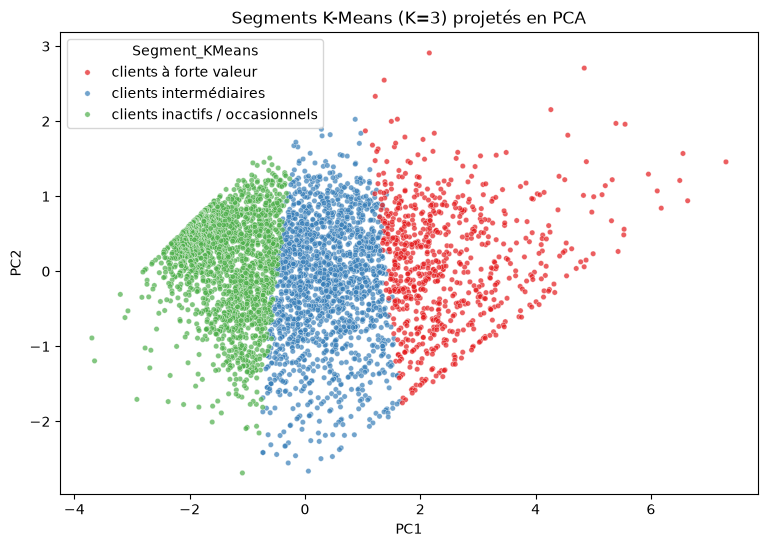

In [59]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=rfm["Segment_KMeans"], palette="Set1", s=15, alpha=0.7)
plt.xlabel("PC1") 
plt.ylabel("PC2")
plt.title("Segments K-Means (K=3) projetés en PCA")
plt.show()